# HormuzWatch — Global Economic Exposure Map
**Question:** Which countries are most exposed to the 2026 Iran war through oil dependency, fertilizer supply chains, refugee flows, and bilateral trade?

**Composite impact score (1–10):** 40% Hormuz oil dependency · 30% fertilizer import exposure · 20% refugee impact · 10% Iran trade volume

**Charts:** `outputs/charts/geo_impact_world.png` · `geo_impact_asia.png` · `geo_impact_bar.png`

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker

ROOT      = Path('..').resolve()
PROCESSED = ROOT / 'data' / 'processed'
CHARTS    = ROOT / 'outputs' / 'charts'
CHARTS.mkdir(parents=True, exist_ok=True)

# Catppuccin dark palette
BG      = '#11111b'
SURFACE = '#1e1e2e'
BORDER  = '#313244'
TEXT    = '#cdd6f4'
SUBTEXT = '#a6adc8'
MUTED   = '#585b70'

# Map color scale: low score → orange → deep red
COLOR_SCALE = [
    [0.0,  '#0d0d1a'],
    [0.2,  '#1a1a35'],
    [0.4,  '#3d2b5a'],
    [0.6,  '#e8b84b'],
    [0.8,  '#e05030'],
    [1.0,  '#ef4444'],
]

print('Imports OK')

Imports OK


## 1. Load country impact data

In [2]:
df = pd.read_csv(PROCESSED / 'country_impact.csv')
print(f'Loaded {len(df)} countries')
print(f'Impact score range: {df["overall_impact_score"].min():.1f} – {df["overall_impact_score"].max():.1f}')
print()

# Summary stats
severely_exposed = df[df['overall_impact_score'] >= 7]
top_country = df.loc[df['overall_impact_score'].idxmax()]

print(f'Countries severely exposed (score \u2265 7): {len(severely_exposed)}')
for _, r in severely_exposed.sort_values('overall_impact_score', ascending=False).iterrows():
    print(f'  {r["country"]:20s}  {r["overall_impact_score"]:.1f}')

print(f'\nTop 15 by impact score:')
top15 = df.nlargest(15, 'overall_impact_score')
for _, r in top15.iterrows():
    bar = '\u2588' * int(r['overall_impact_score'] * 2)
    print(f'  {r["country"]:20s}  {r["overall_impact_score"]:4.1f}  {bar}')

Loaded 29 countries
Impact score range: 0.8 – 9.5

Countries severely exposed (score ≥ 7): 8
  Iraq                  9.5
  Jordan                8.7
  Lebanon               8.6
  Pakistan              8.4
  UAE                   7.6
  Afghanistan           7.5
  Somalia               7.3
  Kenya                 7.1

Top 15 by impact score:
  Iraq                   9.5  ███████████████████
  Jordan                 8.7  █████████████████
  Lebanon                8.6  █████████████████
  Pakistan               8.4  ████████████████
  UAE                    7.6  ███████████████
  Afghanistan            7.5  ███████████████
  Somalia                7.3  ██████████████
  Kenya                  7.1  ██████████████
  Ethiopia               6.9  █████████████
  Japan                  6.7  █████████████
  Taiwan                 6.6  █████████████
  India                  6.5  █████████████
  South Korea            6.1  ████████████
  China                  5.7  ███████████
  Kuwait              

## 2. World choropleth map

In [3]:
# Build hover text
df['hover_text'] = df.apply(lambda r: (
    f"<b>{r['country']}</b><br>"
    f"Impact Score: {r['overall_impact_score']:.1f} / 10<br>"
    f"Hormuz Oil Dependency: {r['hormuz_oil_dependency_pct']}%<br>"
    f"Fertilizer Exposure: {r['fertilizer_import_exposure'].upper()}<br>"
    f"Refugee Impact: {r['refugee_impact'].upper()}<br>"
    f"Iran Trade: ${r['trade_with_iran_usd_bn']:.1f}B/yr"
), axis=1)

GEO_LAYOUT = dict(
    bgcolor='#0a0a12',
    landcolor='#1a1a2e',
    showocean=True,
    oceancolor='#0d0d1a',
    showcoastlines=True,
    coastlinecolor='#2a2a45',
    showcountries=True,
    countrycolor='#252540',
    showframe=False,
    showlakes=False,
    projection_type='natural earth',
)

LAYOUT_BASE = dict(
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(family='monospace', color=TEXT, size=11),
    title_font=dict(size=13, color=TEXT),
    margin=dict(t=55, l=0, r=0, b=10),
    coloraxis=dict(
        colorscale=COLOR_SCALE,
        cmin=0, cmax=10,
        colorbar=dict(
            title=dict(text='Impact Score', font=dict(color=SUBTEXT, size=10)),
            tickfont=dict(color=SUBTEXT, size=9),
            bgcolor=SURFACE,
            bordercolor=BORDER,
            borderwidth=1,
            thickness=12,
            len=0.5,
            x=0.99,
        ),
    ),
)

# World choropleth
fig_world = go.Figure()
fig_world.add_trace(go.Choropleth(
    locations=df['iso3'],
    z=df['overall_impact_score'],
    text=df['hover_text'],
    hovertemplate='%{text}<extra></extra>',
    colorscale=COLOR_SCALE,
    zmin=0, zmax=10,
    colorbar=dict(
        title=dict(text='Impact Score', font=dict(color=SUBTEXT, size=10)),
        tickfont=dict(color=SUBTEXT, size=9),
        bgcolor=SURFACE,
        bordercolor=BORDER,
        borderwidth=1,
        thickness=12,
        len=0.5,
    ),
    showscale=True,
    marker=dict(line=dict(color='#252540', width=0.5)),
))

# Hormuz strait marker
fig_world.add_trace(go.Scattergeo(
    lat=[26.5],
    lon=[56.5],
    mode='markers+text',
    marker=dict(size=9, color='#ef4444', symbol='star', line=dict(color='#fff', width=0.5)),
    text=['Strait of Hormuz'],
    textposition='top right',
    textfont=dict(color='#ef4444', size=9, family='monospace'),
    hoverinfo='skip',
    showlegend=False,
))

fig_world.update_layout(
    title=dict(text='Global Economic Exposure \u2014 2026 Iran War', x=0.02, xanchor='left'),
    geo=dict(
        **GEO_LAYOUT,
        lonaxis=dict(range=[-170, 180]),
        lataxis=dict(range=[-60, 85]),
    ),
    **{k: v for k, v in LAYOUT_BASE.items() if k != 'coloraxis'},
)

out_world = CHARTS / 'geo_impact_world.png'
fig_world.write_image(str(out_world), width=1400, height=780, scale=1.5)
print(f'Saved \u2192 {out_world}')
fig_world.show()

Saved → /Users/amansingh/Desktop/geopolitical_ci/hormuzwatch/outputs/charts/geo_impact_world.png


## 3. Regional zoom — Middle East + Asia

In [4]:
fig_asia = go.Figure()
fig_asia.add_trace(go.Choropleth(
    locations=df['iso3'],
    z=df['overall_impact_score'],
    text=df['hover_text'],
    hovertemplate='%{text}<extra></extra>',
    colorscale=COLOR_SCALE,
    zmin=0, zmax=10,
    colorbar=dict(
        title=dict(text='Impact Score', font=dict(color=SUBTEXT, size=10)),
        tickfont=dict(color=SUBTEXT, size=9),
        bgcolor=SURFACE,
        bordercolor=BORDER,
        borderwidth=1,
        thickness=12,
        len=0.6,
    ),
    showscale=True,
    marker=dict(line=dict(color='#252540', width=0.5)),
))

fig_asia.add_trace(go.Scattergeo(
    lat=[26.5],
    lon=[56.5],
    mode='markers+text',
    marker=dict(size=11, color='#ef4444', symbol='star', line=dict(color='#fff', width=0.5)),
    text=['Strait of Hormuz'],
    textposition='top right',
    textfont=dict(color='#ef4444', size=10, family='monospace'),
    hoverinfo='skip',
    showlegend=False,
))

# Build asia geo dict without conflicting projection_type from GEO_LAYOUT
asia_geo = {k: v for k, v in GEO_LAYOUT.items() if k != 'projection_type'}
asia_geo['projection_type'] = 'mercator'
asia_geo['lonaxis'] = dict(range=[25, 145])
asia_geo['lataxis'] = dict(range=[-5, 52])

fig_asia.update_layout(
    title=dict(text='Middle East + Asia \u2014 Hormuz Exposure Cluster', x=0.02, xanchor='left'),
    geo=asia_geo,
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(family='monospace', color=TEXT, size=11),
    title_font=dict(size=13, color=TEXT),
    margin=dict(t=55, l=0, r=0, b=10),
)

out_asia = CHARTS / 'geo_impact_asia.png'
fig_asia.write_image(str(out_asia), width=1300, height=720, scale=1.5)
print(f'Saved \u2192 {out_asia}')
fig_asia.show()

Saved → /Users/amansingh/Desktop/geopolitical_ci/hormuzwatch/outputs/charts/geo_impact_asia.png


## 4. Top 15 countries — horizontal bar chart

Saved → /Users/amansingh/Desktop/geopolitical_ci/hormuzwatch/outputs/charts/geo_impact_bar.png


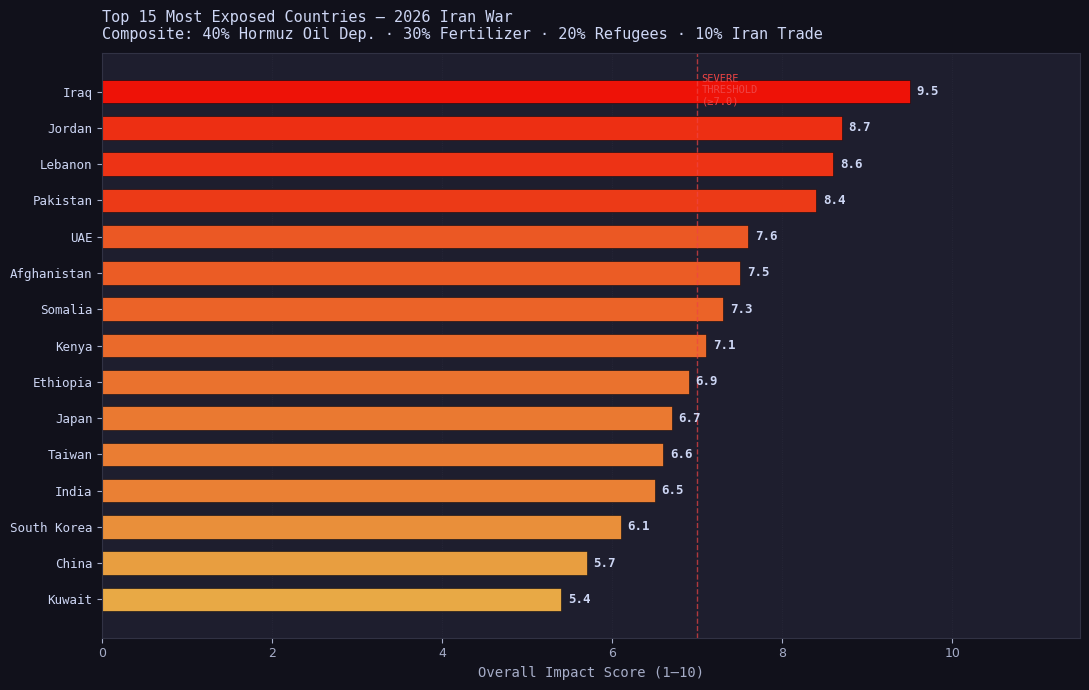

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

top15 = df.nlargest(15, 'overall_impact_score').sort_values('overall_impact_score')

def score_to_color(score, vmin=0, vmax=10):
    t = (score - vmin) / (vmax - vmin)
    if t < 0.5:
        # dark purple → gold
        s = t / 0.5
        r = int(30  + (232 - 30)  * s)
        g = int(30  + (184 - 30)  * s)
        b = int(46  + (75  - 46)  * s)
    else:
        # gold → red
        s = (t - 0.5) / 0.5
        r = int(232 + (239 - 232) * s)
        g = int(184 * (1 - s))
        b = int(75  * (1 - s))
    return f'#{r:02x}{g:02x}{b:02x}'

colors = [score_to_color(s) for s in top15['overall_impact_score']]

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(SURFACE)
for spine in ax.spines.values():
    spine.set_edgecolor(BORDER)

bars = ax.barh(top15['country'], top15['overall_impact_score'],
               color=colors, height=0.65, edgecolor='#0a0a12', linewidth=0.4)

# Score labels
for bar, score in zip(bars, top15['overall_impact_score']):
    ax.text(bar.get_width() + 0.08, bar.get_y() + bar.get_height() / 2,
            f'{score:.1f}', va='center', ha='left',
            color=TEXT, fontsize=9, fontfamily='monospace', fontweight='bold')

# Threshold line at 7
ax.axvline(7, color='#ef4444', lw=1.0, ls='--', alpha=0.7)
ax.text(7.05, len(top15) - 0.5, 'SEVERE\nTHRESHOLD\n(\u22657.0)',
        color='#ef4444', fontsize=7.5, va='top', fontfamily='monospace')

ax.set_xlabel('Overall Impact Score (1\u201310)', fontsize=10, color=SUBTEXT, fontfamily='monospace')
ax.set_title('Top 15 Most Exposed Countries \u2014 2026 Iran War\n'
             'Composite: 40% Hormuz Oil Dep. · 30% Fertilizer · 20% Refugees · 10% Iran Trade',
             fontsize=11, color=TEXT, fontfamily='monospace', loc='left', pad=10)
ax.tick_params(colors=SUBTEXT, labelsize=9)
ax.xaxis.label.set_color(SUBTEXT)
ax.set_xlim(0, 11.5)
plt.setp(ax.get_yticklabels(), fontfamily='monospace', color=TEXT, fontsize=9)
ax.grid(axis='x', color=BORDER, linestyle=':', linewidth=0.6, alpha=0.5)
ax.set_axisbelow(True)

fig.tight_layout()
out_bar = CHARTS / 'geo_impact_bar.png'
fig.savefig(out_bar, dpi=150, bbox_inches='tight', facecolor=BG)
print(f'Saved \u2192 {out_bar}')
plt.show()

## Key findings

### Global Economic Exposure — 2026 Iran War

---

**8 countries score ≥ 7.0 (severely exposed):**

| Country | Score | Primary driver |
|---|---|---|
| **Iraq** | **9.5** | Oil exporter 95% via Hormuz + Iran border + high bilateral trade |
| **Jordan** | **8.7** | 92% oil via Gulf Aqaba + major refugee host + high fertilizer dependency |
| **Lebanon** | **8.6** | 88% oil imports + Hezbollah-Iran nexus + pre-existing economic crisis |
| **Pakistan** | **8.4** | 82% Gulf oil via Hormuz + Iran border + Afghan/Iranian refugee risk |
| **UAE** | **7.6** | 90% oil exports via Hormuz + 100k+ Iranian diaspora + $7.8B Iran trade |
| **Afghanistan** | **7.5** | 58% oil via Pakistan from Gulf + conflict spillover + refugee displacement |
| **Somalia** | **7.3** | 82% Gulf oil imports + fragile state + food security vulnerability |
| **Kenya** | **7.1** | 78% Gulf oil via Mombasa + fertilizer-dependent agriculture + food crisis risk |

**Key geographic patterns:**

1. **East Asian importers (Japan 6.7, Taiwan 6.6, India 6.5, South Korea 6.1):** High scores driven primarily by the fertilizer factor (high=10 for all) and strong Hormuz oil dependency. Japan and Taiwan are most exposed with 87% and 85% oil import dependency respectively. These countries have no domestic oil production and cannot quickly reroute Gulf supply.

2. **Gulf exporters (Iraq, Kuwait, Saudi Arabia, UAE, Qatar) paradox:** The model uses oil *export* dependency on Hormuz for these countries since they produce rather than import oil. Iraq scores highest (9.5) due to stacking of export blockage + massive Iran border trade + internal food/fertilizer import dependency + direct conflict exposure. Saudi Arabia scores lower (4.4) due to minimal refugee impact and limited Iran bilateral trade.

3. **Sub-Saharan food security corridor (Kenya 7.1, Ethiopia 6.9, Somalia 7.3):** These countries have 72–82% Gulf oil import dependency through Djibouti/Mombasa, high fertilizer import exposure, and pre-existing food insecurity. A prolonged Hormuz closure would amplify the fertilizer transmission chain identified in notebook 06.

4. **Middle East refugee corridor (Jordan, Lebanon, Turkey 5.1):** All three score high on refugee impact. Jordan and Lebanon have maximal fertilizer and oil import exposure layered on top, producing the second and third highest scores. Turkey scores moderately overall but is the most exposed European-adjacent nation due to its Iran border trade.

5. **Western insulation (USA 0.9, Canada 0.8, UK 2.0, France 2.2):** The US and Canada are essentially immune to the oil import channel — both are net oil exporters or have fully diversified supply away from Hormuz. European scores are mainly driven by the fertilizer medium exposure (score=5) and potential refugee flows.

**Score methodology:**
```
impact_score = 0.40 × (hormuz_pct / 10)
             + 0.30 × fert_score    (high=10, medium=5, low=2)
             + 0.20 × refugee_score  (high=10, medium=5, low=1)
             + 0.10 × (trade_iran_bn / 14.5 × 10)
```
Sources: IEA World Energy Outlook, IMF Direction of Trade Statistics, UNHCR, UN FAO. All figures are estimates based on pre-war (2024–2025) baseline. Data for oil exporters reflects export dependency on Hormuz, flagged in notes column.

---
*Country impact data: `data/processed/country_impact.csv`. Maps: Plotly choropleth (ISO-3 codes, natural-earth built-in geometry). Bar chart: matplotlib. Strait of Hormuz marker: 26.5°N 56.5°E.*